In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("data.csv")

In [3]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
#tarih,fiyat,yatak odası,banyo,yaşam alanı (m²),arsa alanı,kat sayısı,sahil manzarası,durum,üst kat(m²),bodrum kat(m²),yapım yılı,yenileme yılı,
#sokak,şehir,eyalet,posta kodu,ülke
#regression problemi.bu parametrelere bakarak fiyat tahmini yapacağız.

In [5]:
#skew() Dağılımın simetrik mi, eğik mi olduğunu ölçer.
#0’a yakın → simetrik
#pozitif → sağa çarpık
#negatif → sola çarpık
#sonuç çok yüksek yani target dağılımı ciddi şekilde bozuk.
#log transform yapacağız.

In [6]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
data.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [9]:
data.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [10]:
# 0 price kayıtlarını çıkardık.
data = data[data["price"] > 0]

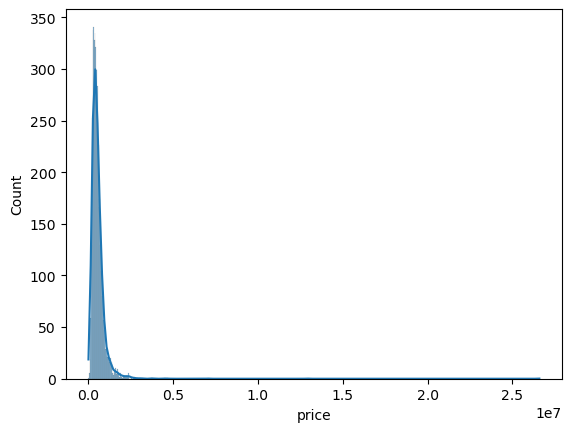

In [11]:
sns.histplot(data["price"],kde=True)
plt.show()

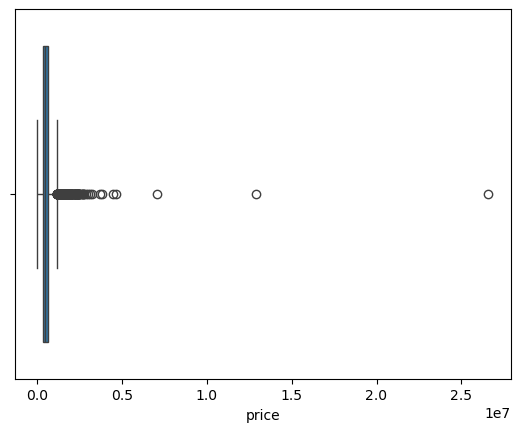

In [12]:
sns.boxplot(x=data["price"])
plt.show()

In [13]:
data.drop(["date"],axis=1,inplace=True)

In [14]:
data.tail()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


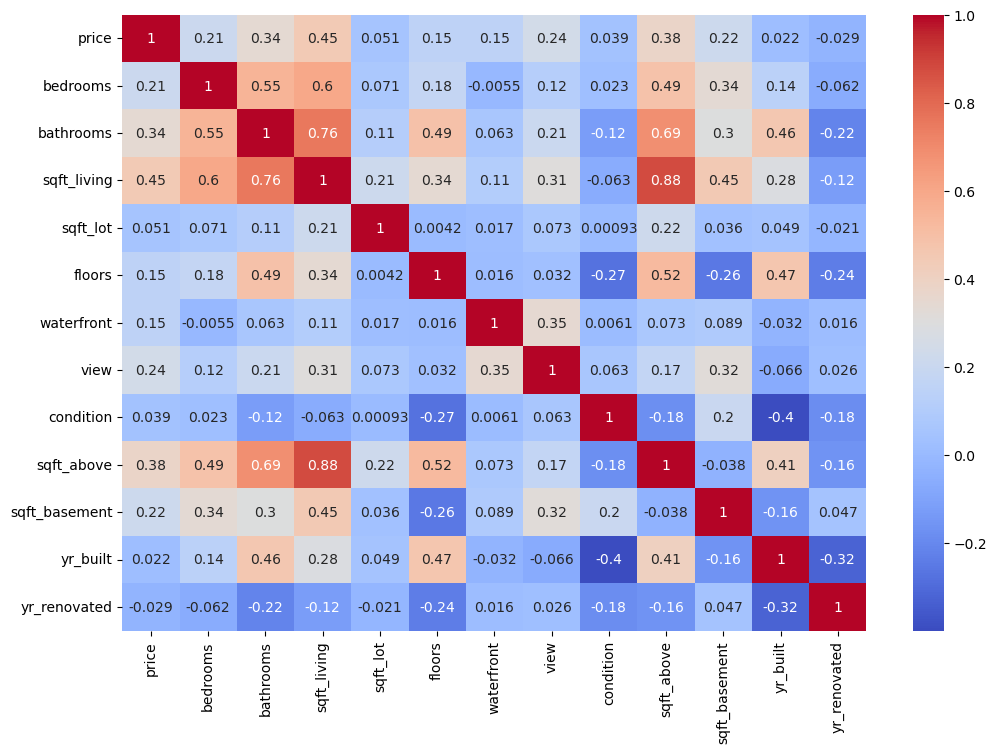

In [15]:
corr=data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

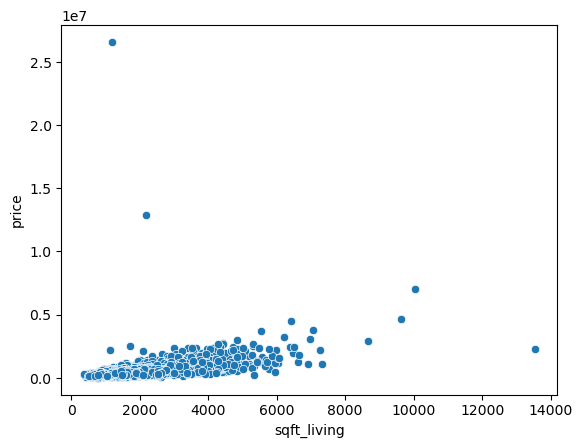

In [16]:
sns.scatterplot(
    x=data["sqft_living"],
    y=data["price"]
)
plt.show()

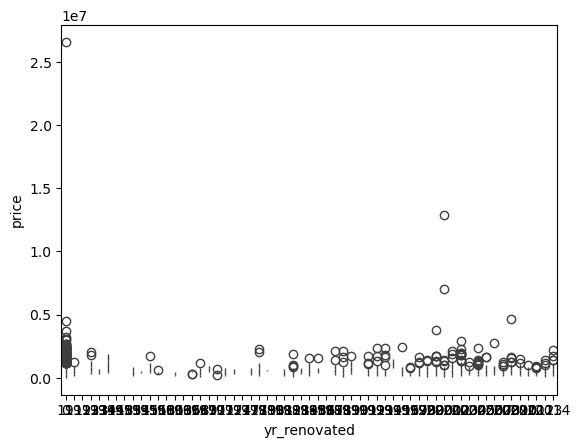

In [17]:
sns.boxplot(
    data=data,
    x="yr_renovated",
    y="price",
    width=0.001
)

plt.show()

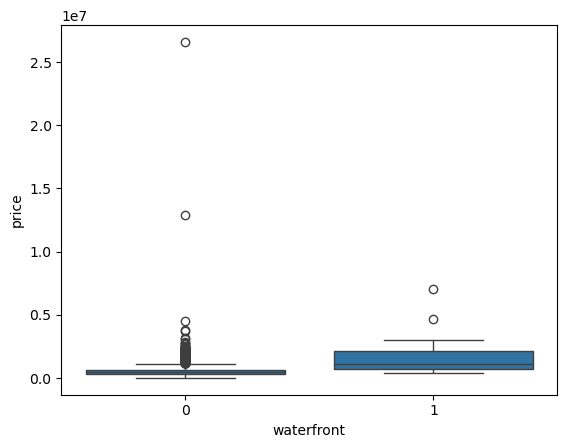

In [18]:
sns.boxplot(
    data=data,
    x="waterfront",
    y="price"
)
plt.show()

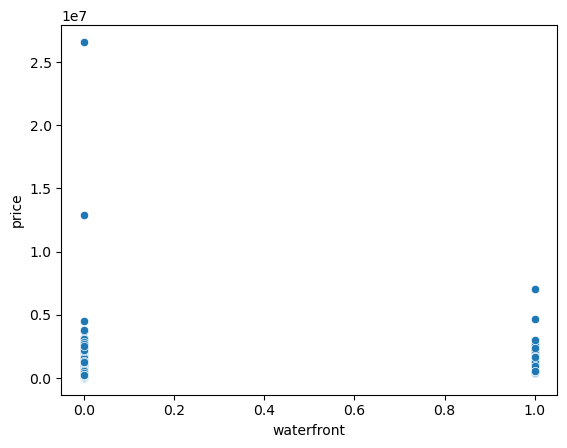

In [19]:
sns.scatterplot(
    data=data,
    x="waterfront",
    y="price"
)
plt.show()

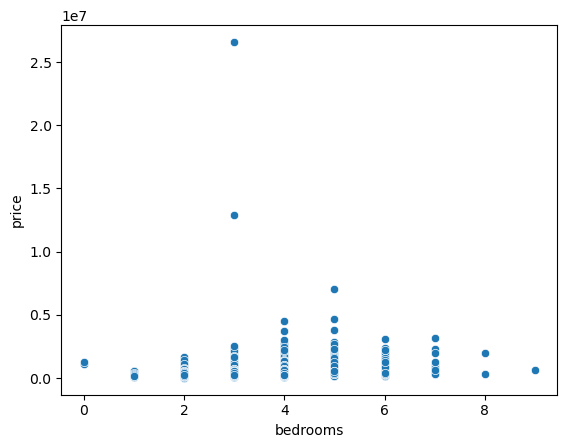

In [20]:
sns.scatterplot(
    data=data,
    x="bedrooms",
    y="price"
)
plt.show()

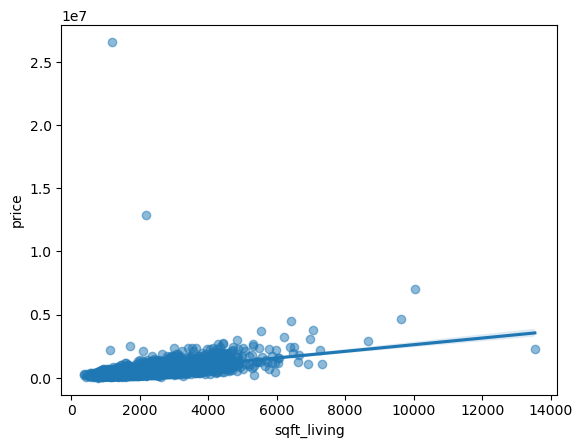

In [21]:
sns.regplot(
    x=data["sqft_living"],
    y=data["price"],
    scatter_kws={"alpha":0.5}
)

plt.show()

In [22]:
data.tail()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [23]:
data.drop("country",axis=1,inplace=True)

In [24]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052


In [25]:
data["street"].nunique()
#Yani neredeyse her evin adresi farklı.
#Bunu one-hot encoding yaparsak yaklaşık 4500 yeni sütun oluşur.o yüzden sil.

4476

In [26]:
data.drop(["street","city"],axis=1,inplace=True)

In [27]:
data.tail()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip
4595,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,WA 98133
4596,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,WA 98007
4597,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,WA 98059
4598,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,WA 98178
4599,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,WA 98042


In [28]:
data["statezip"].nunique()
#encode et.

77

In [29]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,WA 98052


In [30]:
data[["state", "zipcode"]] = data["statezip"].str.split(" ", expand=True)

In [31]:
data.drop("statezip", axis=1, inplace=True)

In [32]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,state,zipcode
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,WA,98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,WA,98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,WA,98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,WA,98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,WA,98052


In [33]:
data["state"].nunique()

1

In [34]:
data.drop("state",axis=1,inplace=True)

In [35]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,98052


In [36]:
data["zipcode"].nunique()

77

In [37]:
data=pd.get_dummies(
    data,
    columns=["zipcode"],
    drop_first=True
)

In [38]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,zipcode_98288,zipcode_98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False


In [39]:
data.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'zipcode_98002', 'zipcode_98003',
       'zipcode_98004', 'zipcode_98005', 'zipcode_98006', 'zipcode_98007',
       'zipcode_98008', 'zipcode_98010', 'zipcode_98011', 'zipcode_98014',
       'zipcode_98019', 'zipcode_98022', 'zipcode_98023', 'zipcode_98024',
       'zipcode_98027', 'zipcode_98028', 'zipcode_98029', 'zipcode_98030',
       'zipcode_98031', 'zipcode_98032', 'zipcode_98033', 'zipcode_98034',
       'zipcode_98038', 'zipcode_98039', 'zipcode_98040', 'zipcode_98042',
       'zipcode_98045', 'zipcode_98047', 'zipcode_98050', 'zipcode_98051',
       'zipcode_98052', 'zipcode_98053', 'zipcode_98055', 'zipcode_98056',
       'zipcode_98057', 'zipcode_98058', 'zipcode_98059', 'zipcode_98065',
       'zipcode_98068', 'zipcode_98070', 'zipcode_98072', 'zipcode_98074',
       'zipcode_98075', 'zipco

In [40]:
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)

In [41]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,zipcode_98288,zipcode_98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,0,0,0,0,0,0,0,0,0,0
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,0,0,0,0,0,0,0,0,0,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,0,0,0,0,0,0,0,0,0,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,0,0,0,0,0,0,0,0,0,0


In [42]:
data.select_dtypes(include=[np.number]).columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'zipcode_98002', 'zipcode_98003',
       'zipcode_98004', 'zipcode_98005', 'zipcode_98006', 'zipcode_98007',
       'zipcode_98008', 'zipcode_98010', 'zipcode_98011', 'zipcode_98014',
       'zipcode_98019', 'zipcode_98022', 'zipcode_98023', 'zipcode_98024',
       'zipcode_98027', 'zipcode_98028', 'zipcode_98029', 'zipcode_98030',
       'zipcode_98031', 'zipcode_98032', 'zipcode_98033', 'zipcode_98034',
       'zipcode_98038', 'zipcode_98039', 'zipcode_98040', 'zipcode_98042',
       'zipcode_98045', 'zipcode_98047', 'zipcode_98050', 'zipcode_98051',
       'zipcode_98052', 'zipcode_98053', 'zipcode_98055', 'zipcode_98056',
       'zipcode_98057', 'zipcode_98058', 'zipcode_98059', 'zipcode_98065',
       'zipcode_98068', 'zipcode_98070', 'zipcode_98072', 'zipcode_98074',
       'zipcode_98075', 'zipco

In [43]:
columns=data.columns
def find_outliers_iqr(data, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = data.select_dtypes(include=[np.number]).columns
    #Kodun "tüm datasetlere uygulanabilir" olmasını sağlayan yer burasıdır.
    #Tablodaki metinleri (string/object) atlar ve sadece sayısal (int/float) sütunları listeler.
    
    for col in numeric_cols:
        #Kodun kalbi olan bu yöntem, veriyi küçükten büyüğe dizer ve 4 parçaya böler.
        #Q1 (%25'lik Dilim): Verinin ilk çeyreği.
        #Q3 (%75'lik Dilim): Verinin üçüncü çeyreği.
        #IQR: Bu iki değerin arasındaki farktır ($IQR = Q3 - Q1$).
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        #Burada "güvenli bölge" oluşturulur. Genellikle threshold (eşik) 1.5 olarak alınır.
        #Lower Bound: Alt sınır. Bunun altındakiler çok küçük uç değerlerdir.
        #Upper Bound: Üst sınır. Bunun üstündekiler çok büyük uç değerlerdir.
        

        outliers = data[ (data[col] < lower_bound) | (data[col] > upper_bound)]
        #altında ve üstünde kalanları outliers değişkenine ata.
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / data.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
        #outlier_count: Kaç tane aykırı değer var?
        #outlier_percentage: Verinin yüzde kaçı aykırı? (Eğer %10'dan fazlaysa veride bir sorun olabilir).
        #Sınırlar: Hangi sayıdan sonrası "aykırı" kabul edildi?
    return pd.DataFrame(outlier_summary)

In [44]:
find_outliers_iqr(data, threshold = 1.5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,zipcode_98288,zipcode_98354
outlier_count,2.400000e+02,115.000000,130.000000,128.000000,540.000000,0.0,30.000000,448.00000,6.000000,111.000000,...,86.000000,57.000000,66.000000,52.000000,47.00000,22.00000,56.000000,67.000000,3.00000,2.000000
outlier_percentage,5.273566e+00,2.526917,2.856515,2.812569,11.865524,0.0,0.659196,9.84399,0.131839,2.439024,...,1.889695,1.252472,1.450231,1.142606,1.03274,0.48341,1.230499,1.472204,0.06592,0.043946
lower_bound,-1.705893e+05,1.500000,0.625000,-265.000000,-3967.000000,-0.5,0.000000,0.00000,1.500000,-475.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
upper_bound,1.154354e+06,5.500000,3.625000,4335.000000,19945.000000,3.5,0.000000,0.00000,5.500000,3965.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000


In [46]:
print("original data shape: ", data.shape)

original data shape:  (4551, 89)


In [47]:
data_target_clean = remove_outliers_from_column(data,"price")

In [48]:
print("remove outliers data shape: ", data_target_clean.shape)
#outlierları temizledikten sonra da r2 score değişmedi.demek ki sorun outlierlar değilmiş.

remove outliers data shape:  (4311, 89)


In [49]:
data["price"]=np.log1p(data["price"])
#normal dağılım yaptık.sola yatıktı ya histplot.
#sonuç yine çok kötü demek ki regression türünde bir hata var.başka tür deneyelim.

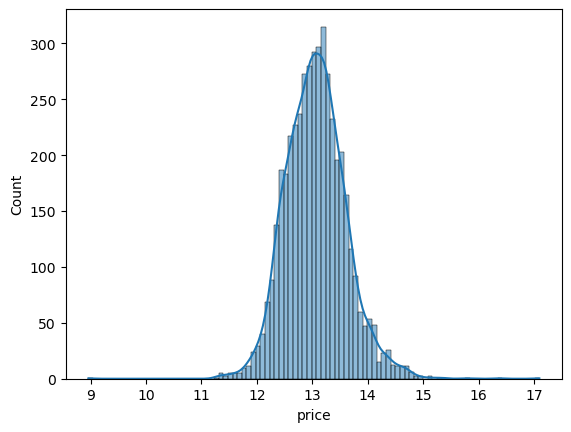

In [50]:
sns.histplot(data["price"],kde=True)
plt.show()

In [51]:
data.drop(
    ["sqft_above","sqft_basement"],
    axis=1,
    inplace=True
)

In [52]:
X=data.drop("price",axis=1)
y=data["price"]

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler=StandardScaler()

In [57]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "Adaboost Regressor" : AdaBoostRegressor(),
    "Gradient Boost Regressor" : GradientBoostingRegressor(),
    "XGBoost Regressor" : XGBRegressor()
}


In [59]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error: ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("-----------------------------------")
    
    print("Model performance for Test Set")
    print("Root Mean Squared Error: ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

    print("-----------------------------------")
    print("\n")


Linear Regression
Model performance for Training Set
Root Mean Squared Error:  0.24357934425076405
Mean Absolute Error:  0.158908738573904
R2 Score:  0.7988450636657228
-----------------------------------
Model performance for Test Set
Root Mean Squared Error:  0.2735123270929258
Mean Absolute Error:  0.17248462630131156
R2 Score:  0.7446128264615413
-----------------------------------


Lasso
Model performance for Training Set
Root Mean Squared Error:  0.5430941311007611
Mean Absolute Error:  0.41962015180697515
R2 Score:  0.0
-----------------------------------
Model performance for Test Set
Root Mean Squared Error:  0.5412740151303891
Mean Absolute Error:  0.42443246430513343
R2 Score:  -0.00018337030285353606
-----------------------------------


Ridge
Model performance for Training Set
Root Mean Squared Error:  0.2435821445439951
Mean Absolute Error:  0.15889414212747457
R2 Score:  0.7988404385112684
-----------------------------------
Model performance for Test Set
Root Mean Squa

In [60]:
linear=LinearRegression()

In [61]:
linear.fit(X_train,y_train)

LinearRegression()

In [62]:
y_train_pred = linear.predict(X_train)
y_test_pred = linear.predict(X_test)

In [63]:
#model neden böyle tahmin ediyor?“Neden Linear en iyi?”
#y=β0​+β1​x1​+β2​x2​+⋯+βn​xn
#y=price x1,x2,..,xn=featurelar
#β=coefficient bu ne demek?
#sqft_living = 0.8 Demek ki:yaşam alanı arttıkça fiyat artıyor ve etkisi güçlü.
coef=pd.DataFrame(
    {
        "feature":X.columns,
        "coefficient":linear.coef_
    }
)


In [64]:
coef=coef.sort_values(
    by="coefficient",
    ascending=False
)

In [65]:
coef.tail(15)

,feature,coefficient
85,zipcode_98354,0.006248
82,zipcode_98198,0.005286
11,zipcode_98003,0.003778
27,zipcode_98030,0.003714
80,zipcode_98178,0.002277
21,zipcode_98022,0.001879
22,zipcode_98023,0.000911
81,zipcode_98188,0.000569
78,zipcode_98168,-0.000922
37,zipcode_98047,-0.001303


In [66]:
coef.head(15)

,feature,coefficient
2,sqft_living,0.262824
12,zipcode_98004,0.141432
62,zipcode_98112,0.134029
63,zipcode_98115,0.132338
56,zipcode_98103,0.132276
65,zipcode_98117,0.128974
40,zipcode_98052,0.126755
34,zipcode_98040,0.116014
30,zipcode_98033,0.114602
83,zipcode_98199,0.111221


In [68]:
#sqft_above ve sqft_basement problemli.Modelde Perfect multicollinearity. var.
#çok büyükler normalde 1,2 çıkması gerekirken bu değerler çok fazla.head e bakınca
#Yani model diyor ki:
#“Bu üç feature aynı bilgiyi veriyor, katsayıları nasıl paylaştıracağımı bilemiyorum.”
#sqft_living=sqft_above+sqft_basement bu neredeyse birebir bağımlılık.
#sqft_living bunu tut diğerlerini sil.
#bunu da üstte modeli eğitmeye başlamadan önce yaptım.
#yeni coefficient değerlerine bakınca gayet anlamlı.

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
pipeline=Pipeline(
    [
        ("scaler",StandardScaler()),
        ("model",LinearRegression())
    ]
)

In [100]:
linear_scores=cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

In [101]:
linear_scores

array([0.81999784, 0.83294934, 0.85557579, 0.85543137, 0.60035432])

In [102]:
linear_scores.mean()
#5 farklı train-test kombinasyonunda model ortalama %79 açıklama gücü gösteriyor.

0.792861734602761

In [103]:
linear_scores.std()
#Fold’lar arasında ne kadar oynama var?
#<0.05  → çok stabil
#0.05–0.10 → iyi
#>0.10 → dikkat

0.09721162475367669

In [104]:
residuals = y_test - y_test_pred

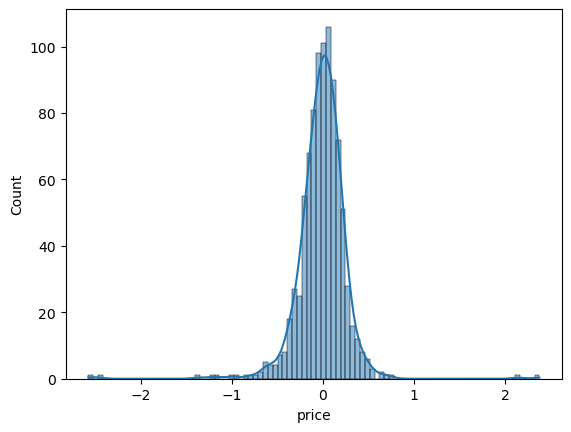

In [105]:
sns.histplot(
    residuals,
    kde=True
)
plt.show()

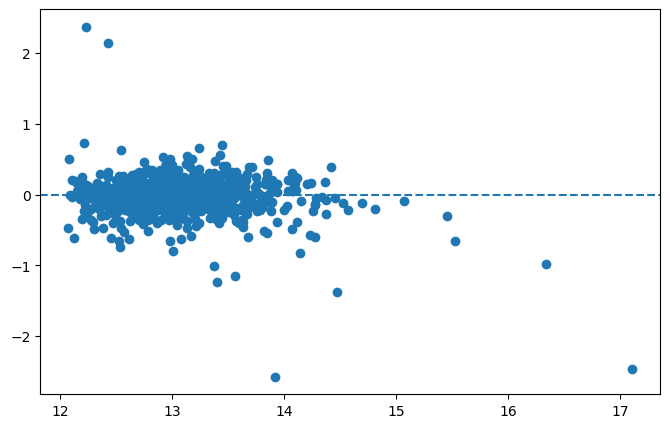

In [106]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.show()

In [141]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV()
ridgecv.fit(X_train,y_train)
y_pred=ridgecv.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("mae:",mae)
print("mse:",mse)
print("r2 score:",score)

mae: 0.17253985716752634
mse: 0.07482298690084534
r2 score: 0.7445650535360775


In [145]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [147]:
ridgecv.alpha_

1.0